#### 1-Introduction

This project builds a PyTorch deep learning pipeline to classify human physical activity using the UCI Human Activity Recognition (HAR) dataset. The data consists of 3-axis accelerometer and gyroscope readings collected at 50Hz from smartphones strapped to volunteers' waists. We'll initially train a Feed Forward Neural Network on the features pre-calculated (over the raw data: inertial signals) and compare the performance with a Convolutive Neural Network running on the raw data.

Import the required libraries/modules for the project:

In [ ]:
import torch
import os
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch.nn.functional as F
from sklearn.manifold import TSNE


#### 2-Neural Network (FFNN) including every features

Now we define the file paths for the project:

In [38]:
x_train_path = 'UCIHARdata/train/X_train.txt'
y_train_path = 'UCIHARdata/train/y_train.txt'
x_test_path = 'UCIHARdata/test/X_test.txt'
y_test_path = 'UCIHARdata/test/y_test.txt'

We load the differents vectors for training and testing (the dataset is already split into to parts) with pandas:

In [39]:
X_train_np = pd.read_csv(x_train_path, delim_whitespace=True, header=None).values
y_train_np = pd.read_csv(y_train_path, delim_whitespace=True, header=None).values.squeeze()
X_test_np = pd.read_csv(x_test_path, delim_whitespace=True, header=None).values
y_test_np = pd.read_csv(y_test_path, delim_whitespace=True, header=None).values.squeeze()

C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\447131672.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train_np = pd.read_csv(x_train_path, delim_whitespace=True, header=None).values
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\447131672.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train_np = pd.read_csv(y_train_path, delim_whitespace=True, header=None).values.squeeze()
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\447131672.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test_np = pd.read_csv(x_test_path, delim_whitespace=True, header=None).values
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\447131672.py:4: FutureWarning: The 'delim_whitespace' keyword in p

We can check that we have indeed 561 features (number of columns), because 561 have been already extracted of the recording, and 7352 row (number of data).

In [40]:
print(np.shape(X_train_np))
print(y_train_np)


(7352, 561)
[5 5 5 ... 2 2 2]


Because, we'll use Pytorch's loss function CrossEntropyLoss, we need to label the activities from 0 to 5 (need to start at 0).

In [41]:
y_train_np = y_train_np - 1
y_test_np = y_test_np - 1

We then convert NumPy arrays to PyTorch Tensors. We need features to be 32-bits floats (GPU optimization).

In [42]:
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

We then creat TensorDatasets and DataLoaders

In [43]:
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# shuffle=True for training ensures the model doesn't memorize the order of the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Success! X_train shape: {X_train_tensor.shape}") # Should be [7352, 561]
print(f"Success! y_train shape: {y_train_tensor.shape}") # Should be [7352]

Success! X_train shape: torch.Size([7352, 561])
Success! y_train shape: torch.Size([7352])


Building a neural network adapted for human activity recognition:

In [44]:
class ActivityNN(nn.Module):
    def __init__(self):
        super(ActivityNN, self).__init__()
        
        # 1st Layer: takes in the 561 features and outputs 256 nodes
        self.fc1 = nn.Linear(in_features=561, out_features=256)
        self.relu1 = nn.ReLU()
        
        # Randomly turns off 20% of neurons during training to prevent the model 
        # from just memorizing the training data (overfitting)
        self.dropout = nn.Dropout(p=0.2)
        
        # 2nd Layer: shrinks the network from 256 nodes down to 128 nodes
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.relu2 = nn.ReLU()
        
        # 3rd Layer: takes the 128 nodes and outputs exactly 6 scores (one for each activity)
        self.fc3 = nn.Linear(in_features=128, out_features=6)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model = ActivityNN()
print(model)

ActivityNN(
  (fc1): Linear(in_features=561, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=6, bias=True)
)


Now we can train and evaluate the model:

In [45]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15

print("Starting training...")
start_time_orig = time.time()

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        
        outputs = model(X_batch)#Forward Pass 
        loss = criterion(outputs, y_batch)#Calculate Loss 
        optimizer.zero_grad()#Zero Gradients 
        loss.backward()#Backward Pass 
        optimizer.step()#Update Weights
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

print("Training complete! Testing on unseen data...")
end_time_orig = time.time()
duration_orig = end_time_orig - start_time_orig
print(f"Original Model finished in: {duration_orig:.2f} seconds")
model.eval() #turns off dropout

correct = 0
total = 0

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        
        # 'outputs' contains 6 raw scores per row. 
        # torch.max finds the highest score and returns its index (the predicted activity 0-5)
        _, predicted = torch.max(outputs.data, 1)
        
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(y_batch.cpu().numpy())

# Calculate final accuracy
accuracy = 100 * correct / total
print(f"Final Test Accuracy: {accuracy:.2f}%")

Starting training...
Epoch 1/15 | Loss: 0.6325
Epoch 2/15 | Loss: 0.2089
Epoch 3/15 | Loss: 0.1419
Epoch 4/15 | Loss: 0.1058
Epoch 5/15 | Loss: 0.1067
Epoch 6/15 | Loss: 0.0821
Epoch 7/15 | Loss: 0.0774
Epoch 8/15 | Loss: 0.0876
Epoch 9/15 | Loss: 0.0673
Epoch 10/15 | Loss: 0.0583
Epoch 11/15 | Loss: 0.0705
Epoch 12/15 | Loss: 0.0581
Epoch 13/15 | Loss: 0.0723
Epoch 14/15 | Loss: 0.0602
Epoch 15/15 | Loss: 0.0493
Training complete! Testing on unseen data...
Original Model finished in: 10.95 seconds
Final Test Accuracy: 95.15%


We reach a final accuracy on the test dataset of around 95%, which is a very convincing result. However, we will try to find ou later where does the 5% of missclassification comes from and how to improve again the accuracy. 
(Note that because the the dataset is evenly distirbuted between each activity, accuracy is a good indicator of how well the model performs.)

#### 3-Dimensionnality Reduction (based on correlation)

Given the fact we have 561 features calculated out of the initial data, it's normal to ask ourselves how correlated the features are and if we can remove some features out of the equations and still have a good accuracy after training. We can already guess that some features are highly correlated (like the jerk and the acceleration as a mere example).

A first approach to estimate approximately how correlated are the features is two create a 561x561 correlation matrix. Of course, this matrix is too big to extract the correlated features, but it's a first step to visualize how correlated they are.

C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\781325816.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  features_df = pd.read_csv(features_path, delim_whitespace=True, header=None, names=['index', 'name'])
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\781325816.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(x_train_path, delim_whitespace=True, header=None)


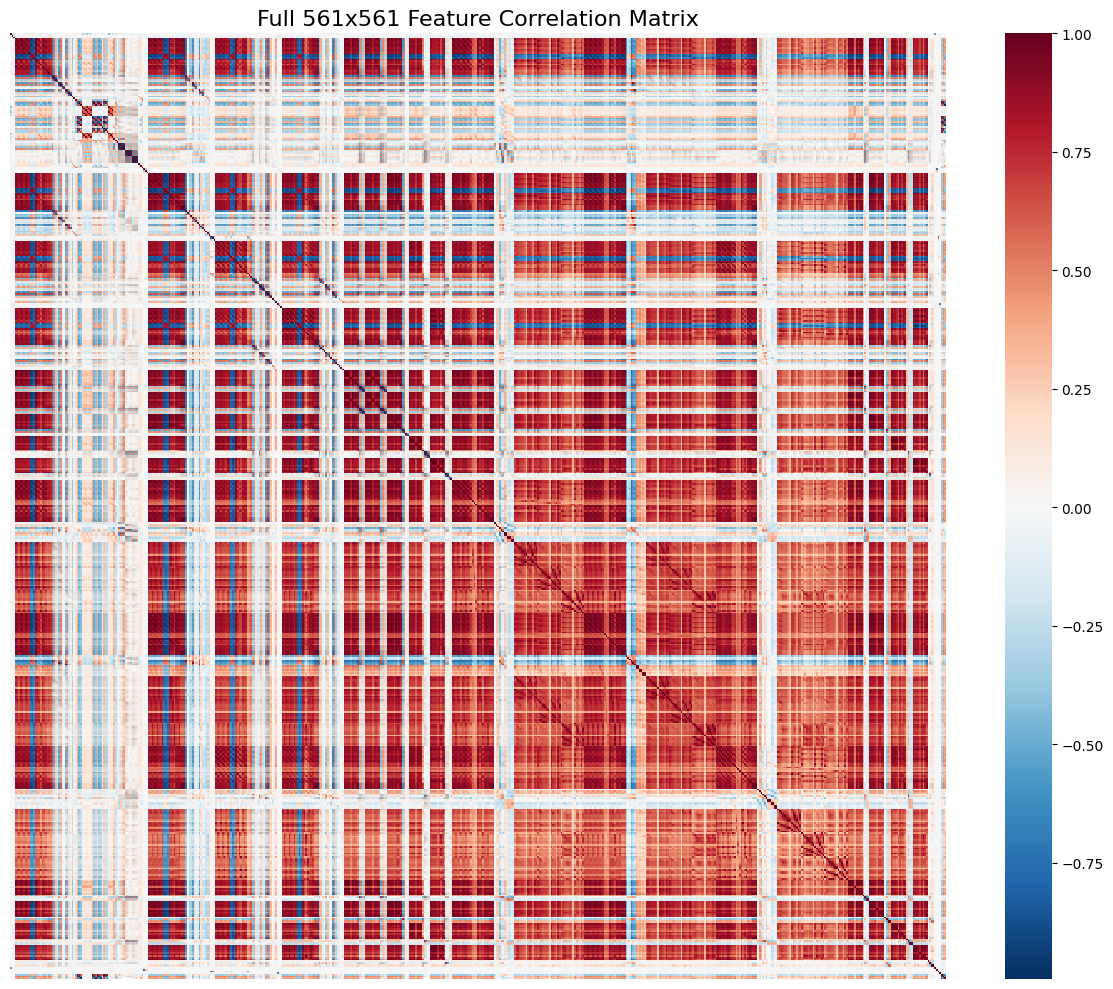

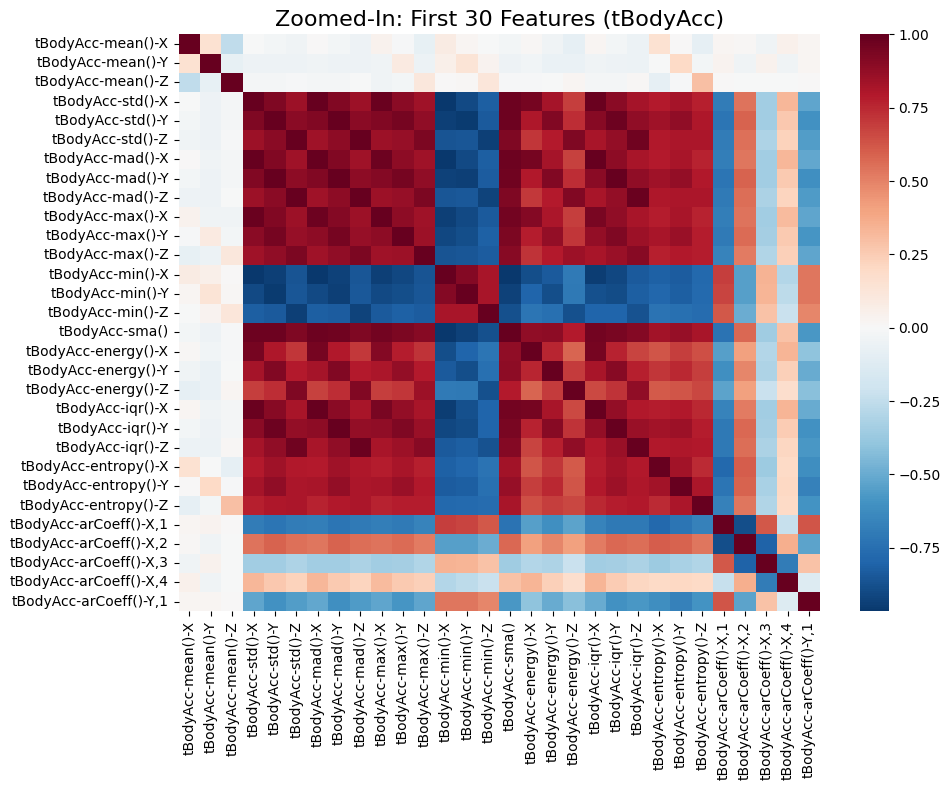

In [46]:
features_path = 'UCIHARdata/features.txt'

features_df = pd.read_csv(features_path, delim_whitespace=True, header=None, names=['index', 'name'])
feature_names = features_df['name'].values

# Load the actual 561 numbers
df = pd.read_csv(x_train_path, delim_whitespace=True, header=None)
df.columns = feature_names
corr_matrix = df.corr()

#first plot of a massive 561x561 heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, xticklabels=False, yticklabels=False)
plt.title("Full 561x561 Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

#second plot with only the 30 first features

plt.figure(figsize=(10, 8))
zoomed_corr = corr_matrix.iloc[:30, :30]

sns.heatmap(zoomed_corr, cmap='RdBu_r', center=0, annot=False, xticklabels=True, yticklabels=True)
plt.title("Zoomed-In: First 30 Features (tBodyAcc)", fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

As we can see on the correlation matrix, a lot of features are highly correlated to others, we will get rid of all these features using the following rule given 0 < x < 1 : if A and B are highly correlated (absolute value of the correlation > x) then drop B.

In [47]:
feature_names = features_df['index'].astype(str) + " - " + features_df['name'] 
#some features have the same name so now every feature name is unique

df = pd.read_csv(x_train_path, delim_whitespace=True, header=None)
df_test= pd.read_csv(x_test_path, delim_whitespace=True, header=None)
df.columns = feature_names
df_test.columns=feature_names

corr_matrix = df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) #avoid duplicates
flat_corr = upper_triangle.unstack().dropna() #transform the matrix into a flat list and drop NaN values

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.90)]

new_nb_features=561-len(to_drop)

print(f"Original number of features: {df.shape[1]}")
print(f"New number of features: {new_nb_features}")

X_train_lean = df.drop(columns=to_drop)
X_test_lean = df_test.drop(columns=to_drop)

print(f"New training shape: {X_train_lean.shape}")
print(f"New testing shape: {X_test_lean.shape}")

C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\1644486704.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(x_train_path, delim_whitespace=True, header=None)
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\1644486704.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_test= pd.read_csv(x_test_path, delim_whitespace=True, header=None)


Original number of features: 561
New number of features: 202
New training shape: (7352, 202)
New testing shape: (2947, 202)


Having our new training and testing dataset (of around 200 features), we can create a new Neural Network called Diet, having less inputs and train it like the first one. 

In [48]:
import torch.nn as nn

class DietActivityNN(nn.Module):
    def __init__(self, input_size=new_nb_features):
        super(DietActivityNN, self).__init__()
        
        self.fc1 = nn.Linear(in_features=input_size, out_features=128)
        self.relu1 = nn.ReLU()
        
        self.dropout = nn.Dropout(p=0.2)
        
        self.fc2 = nn.Linear(in_features=128, out_features=64)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(in_features=64, out_features=6)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        
        x = self.fc3(x)
        return x

diet_model = DietActivityNN(input_size=202)
print(diet_model)

DietActivityNN(
  (fc1): Linear(in_features=202, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=6, bias=True)
)


We can now generate the new tensors and data loaders in order to train and evaluate the Diet Neural Network:

In [49]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_lean.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_lean.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(diet_model.parameters(), lr=0.001)
epochs = 15

start_time_diet = time.time()

for epoch in range(epochs):
    diet_model.train() 
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        
        outputs = diet_model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

end_time_diet = time.time()

duration_diet = end_time_diet - start_time_diet
print(f"Diet Model finished in: {duration_diet:.2f} seconds")

Epoch 1/15 | Loss: 0.9250
Epoch 2/15 | Loss: 0.2982
Epoch 3/15 | Loss: 0.1991
Epoch 4/15 | Loss: 0.1423
Epoch 5/15 | Loss: 0.1196
Epoch 6/15 | Loss: 0.1012
Epoch 7/15 | Loss: 0.0906
Epoch 8/15 | Loss: 0.0805
Epoch 9/15 | Loss: 0.0745
Epoch 10/15 | Loss: 0.0741
Epoch 11/15 | Loss: 0.0661
Epoch 12/15 | Loss: 0.0603
Epoch 13/15 | Loss: 0.0579
Epoch 14/15 | Loss: 0.0498
Epoch 15/15 | Loss: 0.0487
Diet Model finished in: 6.79 seconds


We can then evaluate the model and calculate the accuracy:

In [51]:
diet_model.eval() 

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader: # Use the 202-feature test_loader
        outputs = diet_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Final Diet Model Test Accuracy: {accuracy:.2f}%")

Final Diet Model Test Accuracy: 94.57%


By removing around 350 features (more than half), we still have an accuracy of 93% (only 2% loss compared to the previous case).
(Note that because the training process is non deterministic, we obtain different accuracy values each time we run the code, we could use the K-Fold Cross Validation to produce a more accurate value of accuracy.)

Because we are curious about how the performance of the model will decrease as we decrease the threshold for dropping correlated features, we can try to plot the accuracy (and the number of features) with respect to the threshold x. 

C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\1267388125.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train_df = pd.read_csv('UCIHARdata/train/X_train.txt', delim_whitespace=True, header=None)
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\1267388125.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test_df = pd.read_csv('UCIHARdata/test/X_test.txt', delim_whitespace=True, header=None)


--- Testing Threshold: 0.99 ---
Features remaining: 439 (Dropped 122)
Final Accuracy for threshold 0.99: 94.98%

--- Testing Threshold: 0.95 ---
Features remaining: 253 (Dropped 308)
Final Accuracy for threshold 0.95: 93.38%

--- Testing Threshold: 0.9 ---
Features remaining: 202 (Dropped 359)
Final Accuracy for threshold 0.9: 93.79%

--- Testing Threshold: 0.85 ---
Features remaining: 172 (Dropped 389)
Final Accuracy for threshold 0.85: 93.65%

--- Testing Threshold: 0.8 ---
Features remaining: 145 (Dropped 416)
Final Accuracy for threshold 0.8: 92.87%

--- Testing Threshold: 0.7 ---
Features remaining: 107 (Dropped 454)
Final Accuracy for threshold 0.7: 91.28%

--- Testing Threshold: 0.5 ---
Features remaining: 52 (Dropped 509)
Final Accuracy for threshold 0.5: 87.04%



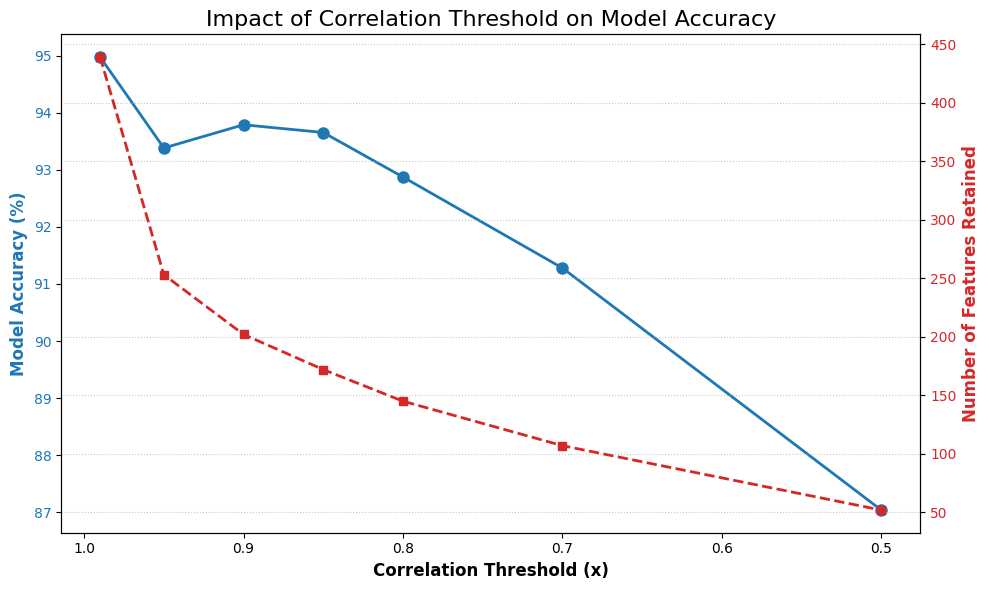

In [52]:
#Dynamic Neural Network to let us change the input size
class DynamicActivityNN(nn.Module):
    def __init__(self, input_size):
        super(DynamicActivityNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 6)

    def forward(self, x):
        x = self.dropout(self.relu1(self.fc1(x)))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

X_train_df = pd.read_csv('UCIHARdata/train/X_train.txt', delim_whitespace=True, header=None)
X_test_df = pd.read_csv('UCIHARdata/test/X_test.txt', delim_whitespace=True, header=None)
corr_matrix = X_train_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#list of correlation thresholds we want to test
thresholds = [0.99, 0.95, 0.90, 0.85, 0.80, 0.70, 0.50]

results_accuracy = []
results_feature_count = []

epochs = 15
batch_size = 64

for x in thresholds:
    print(f"--- Testing Threshold: {x} ---")
    to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > x)]
    
    X_train_lean = X_train_df.drop(columns=to_drop)
    X_test_lean = X_test_df.drop(columns=to_drop)
    
    current_feature_count = X_train_lean.shape[1]
    results_feature_count.append(current_feature_count)
    print(f"Features remaining: {current_feature_count} (Dropped {len(to_drop)})")
    
    #create DataLoaders
    X_train_tensor = torch.tensor(X_train_lean.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test_lean.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)
    
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)
    
    #Model sized for this input
    model = DynamicActivityNN(input_size=current_feature_count)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    #train the model
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            
    #evaluate the model
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            
    accuracy = 100 * correct / total
    results_accuracy.append(accuracy)
    print(f"Final Accuracy for threshold {x}: {accuracy:.2f}%\n")


fig, ax1 = plt.subplots(figsize=(10, 6))

#accuracy
color = 'tab:blue'
ax1.set_xlabel('Correlation Threshold (x)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Model Accuracy (%)', color=color, fontsize=12, fontweight='bold')
ax1.plot(thresholds, results_accuracy, marker='o', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.invert_xaxis() 

#feature count
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Number of Features Retained', color=color, fontsize=12, fontweight='bold')  
ax2.plot(thresholds, results_feature_count, marker='s', linestyle='--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of Correlation Threshold on Model Accuracy', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

The result is as expected, as the correlation threshold increase, the number of features decrease (naturally) and the model accuracy is decreasing as well but the slope is not to steep. Even after removing 90% of the features (threshold x=0.5), the accuracy is still 87%.

#### 4-Hunting Down the 5%

As seen when training the Neural Network, it reaches an accuracy of 95% on unseen data. In this section, we would like to determine where do the mistakes come from and if it's possible to get closer to a 100% accuracy.

We can start by analyzing where errors occurs during evaluation by generating the confusion matrix (dataset with 561 features). 

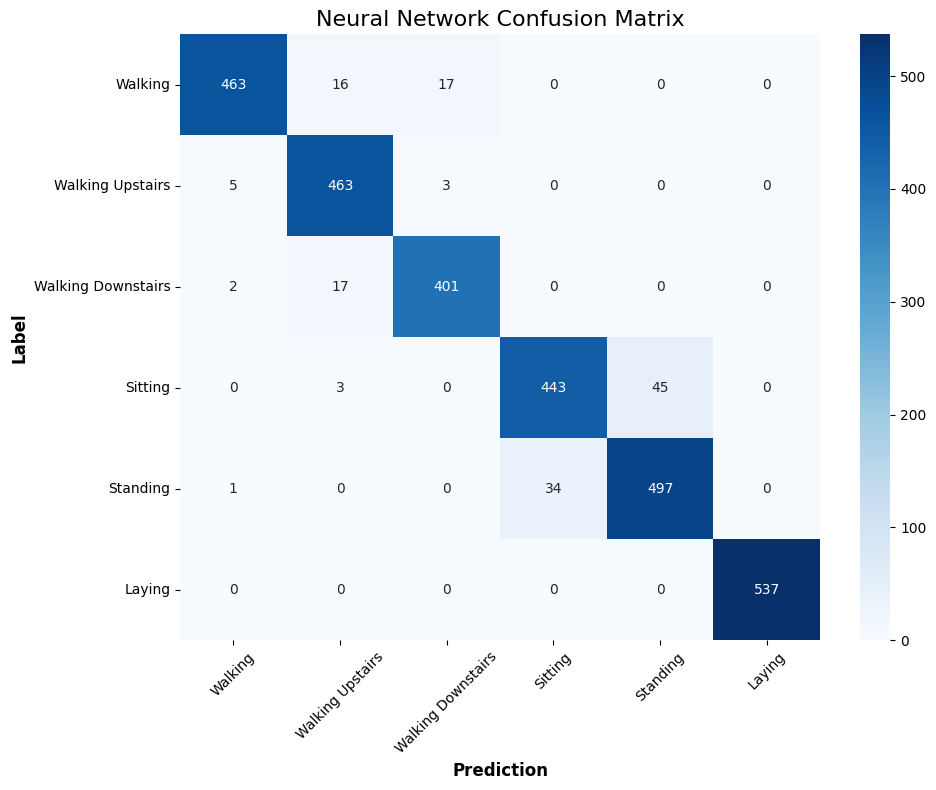

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_true_labels, all_predictions)

activity_names = [
    "Walking", 
    "Walking Upstairs", 
    "Walking Downstairs", 
    "Sitting", 
    "Standing", 
    "Laying"
]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=activity_names, 
            yticklabels=activity_names)

plt.xlabel('Prediction', fontsize=12, fontweight='bold')
plt.ylabel('Label', fontsize=12, fontweight='bold')
plt.title('Neural Network Confusion Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The confusion matrix highlights activities the network has hard times to classify, it struggles making the difference between Walking/Walking Upstair/Walking Downstair and mainly with the difference between Standing and Sitting (which makes sense because in either case the smartphone is standing vertically and do not move).

We can now look at the data quality by using t-SNE method.

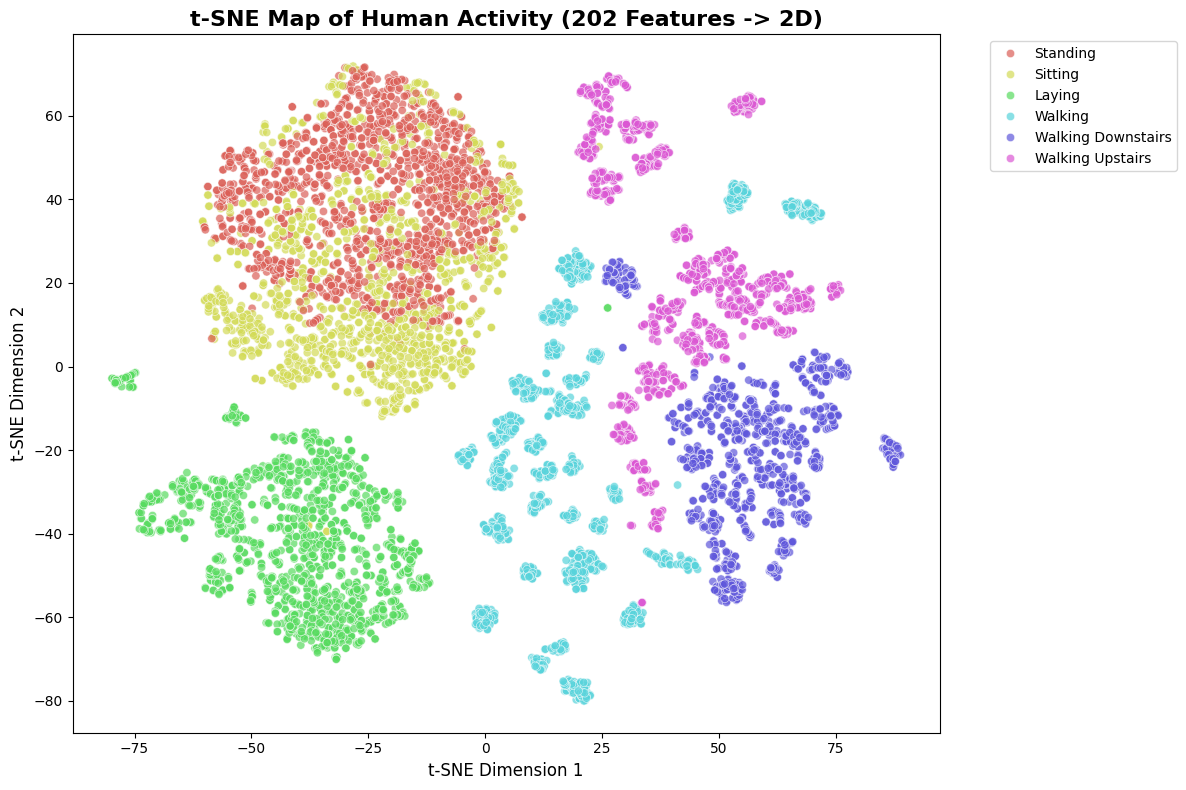

In [54]:
tsne = TSNE(n_components=2, random_state=42)

X_tsne = tsne.fit_transform(X_train_np)

tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE_X', 'TSNE_Y'])

activity_map = {
    0: "Walking", 1: "Walking Upstairs", 2: "Walking Downstairs", 
    3: "Sitting", 4: "Standing", 5: "Laying"
}

tsne_df['Activity'] = pd.Series(y_train_np).map(activity_map)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TSNE_X', y='TSNE_Y',
    hue='Activity',
    palette=sns.color_palette("hls", 6),
    data=tsne_df,
    legend="full",
    alpha=0.7 
)

plt.title('t-SNE Map of Human Activity (202 Features -> 2D)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

On the t-SNE map we can obviously separate activities from "moving" ones, like walking, walking upstairs/downstairs, which implies continuous iterative motion, and "motionless" one, like Standing, Sitting or Laying. Those 2 different groups are separated along the dimension 1 by a huge white gap. 

Although, we immediatly distinguish the island formed by "Sitting" and "Standing", highlighting the fact that those 2 activities will be hard to distinguish by any kind of model. 

An assumption: because the activity is recorded in 2.56-second windows, there are likely many segments where it is impossible to distinguish between sitting and standing. In such cases, it would be preferable to analyze the full recording rather than relying on individual windows.

#### 5-CNN 1D

In the first model, we used pre-calculated features on the recording to extract insights with a FFNN, however, we could also naturally think about using a Convolutive Neural Network (CNN 1D) directly on the raw data (the inertial signals windows). Intuitively, we could increase accuracy because the Convolutive Neural Network might be able to spot some small movement (for example while standing, the body should move back and forth slighty and features cannot spot this movement), but it's only an assumption. Let's then turn the raw data into training dataset.

In [55]:
def load_raw_signals(base_path, subset='train'):
    """
    Loads the 9 raw time-series files and stacks them into a 3D Numpy array.
    """
    signal_names = [
        "body_acc_x", "body_acc_y", "body_acc_z",
        "body_gyro_x", "body_gyro_y", "body_gyro_z",
        "total_acc_x", "total_acc_y", "total_acc_z"
    ]
    loaded_signals = []
    
    for signal in signal_names:
        filepath = os.path.join(base_path, subset, 'Inertial Signals', f"{signal}_{subset}.txt")
        df = pd.read_csv(filepath, delim_whitespace=True, header=None)
        loaded_signals.append(df.values)
        
    X_3D = np.stack(loaded_signals, axis=1) #pytorch structure time series data: [Batch_Size, Channels, Sequence_Length]
    
    return X_3D

X_train_CNN = load_raw_signals('UCIHARdata', subset='train')
X_test_CNN = load_raw_signals('UCIHARdata', subset='test')


print(f"Final Data Shape: {X_train_CNN.shape}") # should print (7352, 9, 128)
print(f"Final Data Shape: {X_test_CNN.shape}") # should print (2947, 9, 128)

C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\2734386100.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None)
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\2734386100.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None)
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\2734386100.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, header=None)
C:\Users\aclai\AppData\Local\Temp\ipykernel_16788\2734386100.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future 

Final Data Shape: (7352, 9, 128)
Final Data Shape: (2947, 9, 128)


Now we can turn our dataset into tensors to train our model:

In [56]:
X_train_tensor_CNN = torch.tensor(X_train_CNN, dtype=torch.float32)
X_test_tensor_CNN = torch.tensor(X_test_CNN, dtype=torch.float32)

train_CNN_dataset = TensorDataset(X_train_tensor_CNN, y_train_tensor)
test_CNN_dataset = TensorDataset(X_test_tensor_CNN, y_test_tensor)

train_loader_CNN = DataLoader(train_CNN_dataset, batch_size=64, shuffle=True)
test_loader_CNN = DataLoader(test_CNN_dataset, batch_size=64, shuffle=False)

We can then define our Convolutive Neural Network:

In [57]:
class HAR_1DCNN(nn.Module):
    def __init__(self):
        super(HAR_1DCNN, self).__init__()
        # ============
        # CONVOLUTION
        # ============

        # 1st convolution layer
        self.conv1 = nn.Conv1d(in_channels=9, out_channels=64, kernel_size=3)
        # 1st pooling layer (divide the size by half)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        # 2nd convolution layer
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3)
        # 2nd Pooling Layer
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        # ===========   
        # CLASSIFIER
        # ===========
        
        # input: 128 steps
        # after conv1 (kernel 3): 128 - 3 + 1 = 126 steps
        # after pool1 (kernel 2): 126 / 2 = 63 steps
        # after conv2 (kernel 3): 63 - 3 + 1 = 61 steps
        # after pool2 (kernel 2): 61 / 2 = 30 steps
        # final flattened size = 128 channels * 30 steps = 3840
        self.flattened_size = 128 * 30
        
        self.fc1 = nn.Linear(in_features=self.flattened_size, out_features=128)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=128, out_features=6)

    def forward(self, x):
        # Input x shape: [Batch_Size, 9, 128]
        
        x = self.conv1(x)            #->[Batch_Size, 64, 126]
        x = F.relu(x)
        x = self.pool1(x)            #->[Batch_Size, 64, 63]
        
        x = self.conv2(x)            #->[Batch_Size, 128, 61]
        x = F.relu(x)
        x = self.pool2(x)            #->[Batch_Size, 128, 30]
        
        x = x.view(x.size(0), -1)    #->[Batch_Size, 3840]
        
        x = self.fc1(x)              #->[Batch_Size, 128]
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)              #->[Batch_Size, 6]
        
        return x

To test the sanity of our model (the structure), we can pump a dummy tensor through it:

In [58]:
model = HAR_1DCNN()
dummy_input = torch.randn(64, 9, 128)
dummy_output = model(dummy_input)
print(f"input shape: {dummy_input.shape}")
print(f"output shape: {dummy_output.shape}") #should equal 64x6

input shape: torch.Size([64, 9, 128])
output shape: torch.Size([64, 6])


We can now train the model:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}\n")

model = HAR_1DCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) #using Adam Optimizer
epochs = 15

for epoch in range(epochs):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for batch_X, batch_y in train_loader_CNN:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X) #forward pass
        loss = criterion(outputs, batch_y) #calculate error
        loss.backward() #backward pass
        optimizer.step() #adjust kernel weights
        
        # statistics
        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == batch_y).sum().item()
        total_samples += batch_y.size(0)
        
    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions / total_samples) * 100
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Training on device: cpu

Epoch 01/20 | Loss: 0.6185 | Accuracy: 75.11%
Epoch 02/20 | Loss: 0.2413 | Accuracy: 91.19%
Epoch 03/20 | Loss: 0.1509 | Accuracy: 94.19%
Epoch 04/20 | Loss: 0.1310 | Accuracy: 94.82%
Epoch 05/20 | Loss: 0.1191 | Accuracy: 95.14%
Epoch 06/20 | Loss: 0.1098 | Accuracy: 94.98%
Epoch 07/20 | Loss: 0.1075 | Accuracy: 95.28%
Epoch 08/20 | Loss: 0.1066 | Accuracy: 95.28%
Epoch 09/20 | Loss: 0.0997 | Accuracy: 95.42%
Epoch 10/20 | Loss: 0.0956 | Accuracy: 95.50%
Epoch 11/20 | Loss: 0.0913 | Accuracy: 95.57%
Epoch 12/20 | Loss: 0.1061 | Accuracy: 95.25%
Epoch 13/20 | Loss: 0.0896 | Accuracy: 95.89%
Epoch 14/20 | Loss: 0.0916 | Accuracy: 95.61%
Epoch 15/20 | Loss: 0.0780 | Accuracy: 95.97%
Epoch 16/20 | Loss: 0.0803 | Accuracy: 95.97%
Epoch 17/20 | Loss: 0.0771 | Accuracy: 95.91%
Epoch 18/20 | Loss: 0.0733 | Accuracy: 96.38%
Epoch 19/20 | Loss: 0.0769 | Accuracy: 95.95%
Epoch 20/20 | Loss: 0.0683 | Accuracy: 96.61%


Finally, we can evaluate the model on the test dataset:

In [66]:
from sklearn.metrics import accuracy_score

model.eval()

all_predictions = []
all_true_labels = []

# torch.no_grad turns off the calculus engine to save memory and speed up testing
with torch.no_grad():
    for batch_X, batch_y in test_loader_CNN:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        
        # results
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(batch_y.numpy())

# final accuracy on test dataset
final_accuracy = accuracy_score(all_true_labels, all_predictions) * 100
print(f"\nFinal Test Accuracy: {final_accuracy:.2f}%")


Final Test Accuracy: 90.94%


The result is slightly disappoiting, given that the accuracy is lower than the accuracy we obtained previously with the FeedForward Neural Network, we can again drawn the confusion matrix.

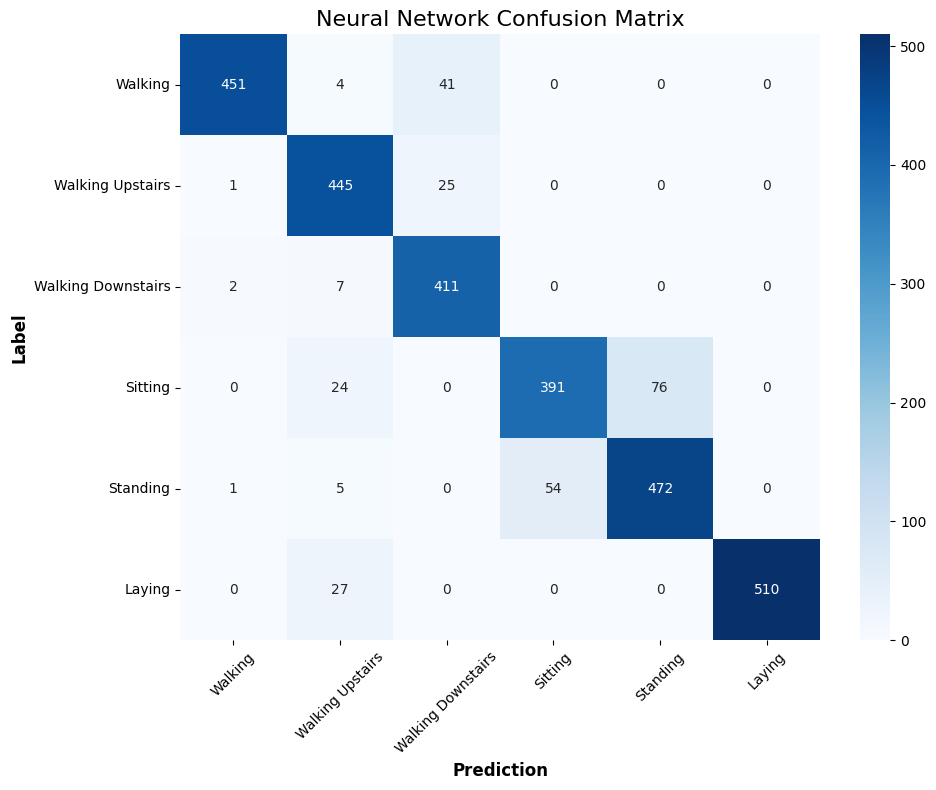

In [67]:
cm = confusion_matrix(all_true_labels, all_predictions)

activity_names = [
    "Walking", 
    "Walking Upstairs", 
    "Walking Downstairs", 
    "Sitting", 
    "Standing", 
    "Laying"
]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=activity_names, 
            yticklabels=activity_names)

plt.xlabel('Prediction', fontsize=12, fontweight='bold')
plt.ylabel('Label', fontsize=12, fontweight='bold')
plt.title('Neural Network Confusion Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Changing the model of the structure here does not work, it struggle again to make the difference between sitting and standing.